### Import packages

In [1]:
import pandas as pd
import krippendorff
from scipy.stats import spearmanr
import re
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

### Load responses

In [2]:
df = pd.read_csv('outputs/human_annotations.csv')

In [3]:
# df = df[:2]

df

,Timestamp,Wie alt bist du?,Wie oft nutzt du Reddit?,Wie gut schätzt du dich selbst ein Ironie im Alltag erkennen zu können?,Wie gut kennst du r/de?,KOMMENTAR #1\n\nTHREAD: Mehrheit sieht ältere im Vorteil - nicht einmal ein Drittel der jungen glaubt an faire Rente\n\nKOMMENTAR: Solange alle ihre Tiefkühlpizza und RTL haben ist doch alles super!\n\nWie ironisch ist dieser Kommentar?,Wie sicher bist du dir bei dieser Einschätzung?,KOMMENTAR #2\n\nTHREAD: Mehrheit sieht ältere im Vorteil - nicht einmal ein Drittel der jungen glaubt an faire Rente\n\nKOMMENTAR: Ich bin schockiert.\n\nWie ironisch ist dieser Kommentar?,Wie sicher bist du dir bei dieser Einschätzung?.1,"KOMMENTAR #3\n\nTHREAD: Mehrheit sieht ältere im Vorteil - nicht einmal ein Drittel der jungen glaubt an faire Rente\n\nKOMMENTAR: Würden sich die babyboomer zu Tode arbeiten, bräuchte man ihnen keine Rente mehr zahlen\n\nWie ironisch ist dieser Kommentar?",...,KOMMENTAR #56\n\nTHREAD: EU-Einigung scheitert: Freiwillige Chatkontrolle endet\n\nKOMMENTAR: Für heute?\n\nWie ironisch ist dieser Kommentar?,Wie sicher bist du dir bei dieser Einschätzung?.55,KOMMENTAR #57\n\nTHREAD: EU-Einigung scheitert: Freiwillige Chatkontrolle endet\n\nKOMMENTAR: Soll ich nochmal?\n\nWie ironisch ist dieser Kommentar?,Wie sicher bist du dir bei dieser Einschätzung?.56,KOMMENTAR #58\n\nTHREAD: CDU fordert Aufklärung über Verwendung des Sondervermögens\n\nKOMMENTAR: Da kann Reiche gleich die nächste Arbeitsgruppe gründen um das ganze zu verschleppen\n\nWie ironisch ist dieser Kommentar?,Wie sicher bist du dir bei dieser Einschätzung?.57,KOMMENTAR #59\n\nTHREAD: Verschwörungs-Demo in Berlin: Xavier Naidoo singt - deutlich weniger Teilnehmende als angekündigt\n\nKOMMENTAR: Gabs da auch embryonal gewürzte Currywurst mit Pommes?\n\nWie ironisch ist dieser Kommentar?,Wie sicher bist du dir bei dieser Einschätzung?.58,KOMMENTAR #60\n\nTHREAD: Verschwörungs-Demo in Berlin: Xavier Naidoo singt - deutlich weniger Teilnehmende als angekündigt\n\nKOMMENTAR: Dieser Weg ist peinlich und leer.\n\nWie ironisch ist dieser Kommentar?,Wie sicher bist du dir bei dieser Einschätzung?.59
0,18/03/2026 14:32:07,18-24,Selten,5,"Kenne ich, lese selten",5,5,3,3,5,...,5,4,5,4,4,4,5,4,5,4
1,18/03/2026 14:33:51,18-24,"Kenne Reddit, nutze es kaum",4,Kenne ich nicht,4,4,3,3,3,...,5,5,5,5,4,2,5,5,2,5
2,18/03/2026 14:35:06,18-24,Selten,5,"Kenne ich, lese selten",4,4,3,4,2,...,4,5,5,5,4,4,5,5,1,3
3,18/03/2026 14:35:12,18-24,"Kenne Reddit, nutze es kaum",4,Kenne ich nicht,4,4,3,4,2,...,4,4,4,5,3,3,5,5,5,5
4,18/03/2026 14:35:38,35-44,"Kenne Reddit, nutze es kaum",4,Kenne ich nicht,5,4,4,3,5,...,3,2,2,1,4,3,3,4,3,3
5,18/03/2026 14:36:38,18-24,"Kenne Reddit, nutze es kaum",3,Kenne ich nicht,5,4,1,4,3,...,5,4,5,4,3,3,5,5,5,5
6,18/03/2026 14:37:08,18-24,Kenne Reddit nicht,3,Kenne ich nicht,4,4,1,4,3,...,5,5,5,5,3,3,5,5,4,2
7,18/03/2026 14:39:48,25-34,Täglich,5,"Kenne ich, lese selten",5,4,4,4,5,...,5,5,3,2,4,5,5,4,5,5
8,18/03/2026 14:39:48,25-34,"Kenne Reddit, nutze es kaum",4,Kenne ich nicht,5,5,3,3,5,...,4,4,4,3,4,3,5,5,2,4


### Split data into general info and comment rating

In [4]:
general_info = df.iloc[:, :4]

general_info

,Timestamp,Wie alt bist du?,Wie oft nutzt du Reddit?,Wie gut schätzt du dich selbst ein Ironie im Alltag erkennen zu können?
0,18/03/2026 14:32:07,18-24,Selten,5
1,18/03/2026 14:33:51,18-24,"Kenne Reddit, nutze es kaum",4
2,18/03/2026 14:35:06,18-24,Selten,5
3,18/03/2026 14:35:12,18-24,"Kenne Reddit, nutze es kaum",4
4,18/03/2026 14:35:38,35-44,"Kenne Reddit, nutze es kaum",4
5,18/03/2026 14:36:38,18-24,"Kenne Reddit, nutze es kaum",3
6,18/03/2026 14:37:08,18-24,Kenne Reddit nicht,3
7,18/03/2026 14:39:48,25-34,Täglich,5
8,18/03/2026 14:39:48,25-34,"Kenne Reddit, nutze es kaum",4


In [5]:
comment_rating = df.iloc[:, 5:]

comment_rating

,KOMMENTAR #1\n\nTHREAD: Mehrheit sieht ältere im Vorteil - nicht einmal ein Drittel der jungen glaubt an faire Rente\n\nKOMMENTAR: Solange alle ihre Tiefkühlpizza und RTL haben ist doch alles super!\n\nWie ironisch ist dieser Kommentar?,Wie sicher bist du dir bei dieser Einschätzung?,KOMMENTAR #2\n\nTHREAD: Mehrheit sieht ältere im Vorteil - nicht einmal ein Drittel der jungen glaubt an faire Rente\n\nKOMMENTAR: Ich bin schockiert.\n\nWie ironisch ist dieser Kommentar?,Wie sicher bist du dir bei dieser Einschätzung?.1,"KOMMENTAR #3\n\nTHREAD: Mehrheit sieht ältere im Vorteil - nicht einmal ein Drittel der jungen glaubt an faire Rente\n\nKOMMENTAR: Würden sich die babyboomer zu Tode arbeiten, bräuchte man ihnen keine Rente mehr zahlen\n\nWie ironisch ist dieser Kommentar?",Wie sicher bist du dir bei dieser Einschätzung?.2,KOMMENTAR #4\n\nTHREAD: Mehrheit sieht ältere im Vorteil - nicht einmal ein Drittel der jungen glaubt an faire Rente\n\nKOMMENTAR: Auf den Schreck erstmal eine Rentenerhöhung.\n\nWie ironisch ist dieser Kommentar?,Wie sicher bist du dir bei dieser Einschätzung?.3,KOMMENTAR #5\n\nTHREAD: Mehrheit sieht ältere im Vorteil - nicht einmal ein Drittel der jungen glaubt an faire Rente\n\nKOMMENTAR: Finde den Generationen-Vertrag an sich schon dämlich. Will meine eigene Rente auffüllen und nicht die von anderen.\n\nWie ironisch ist dieser Kommentar?,Wie sicher bist du dir bei dieser Einschätzung?.4,...,KOMMENTAR #56\n\nTHREAD: EU-Einigung scheitert: Freiwillige Chatkontrolle endet\n\nKOMMENTAR: Für heute?\n\nWie ironisch ist dieser Kommentar?,Wie sicher bist du dir bei dieser Einschätzung?.55,KOMMENTAR #57\n\nTHREAD: EU-Einigung scheitert: Freiwillige Chatkontrolle endet\n\nKOMMENTAR: Soll ich nochmal?\n\nWie ironisch ist dieser Kommentar?,Wie sicher bist du dir bei dieser Einschätzung?.56,KOMMENTAR #58\n\nTHREAD: CDU fordert Aufklärung über Verwendung des Sondervermögens\n\nKOMMENTAR: Da kann Reiche gleich die nächste Arbeitsgruppe gründen um das ganze zu verschleppen\n\nWie ironisch ist dieser Kommentar?,Wie sicher bist du dir bei dieser Einschätzung?.57,KOMMENTAR #59\n\nTHREAD: Verschwörungs-Demo in Berlin: Xavier Naidoo singt - deutlich weniger Teilnehmende als angekündigt\n\nKOMMENTAR: Gabs da auch embryonal gewürzte Currywurst mit Pommes?\n\nWie ironisch ist dieser Kommentar?,Wie sicher bist du dir bei dieser Einschätzung?.58,KOMMENTAR #60\n\nTHREAD: Verschwörungs-Demo in Berlin: Xavier Naidoo singt - deutlich weniger Teilnehmende als angekündigt\n\nKOMMENTAR: Dieser Weg ist peinlich und leer.\n\nWie ironisch ist dieser Kommentar?,Wie sicher bist du dir bei dieser Einschätzung?.59
0,5,5,3,3,5,4,5,5,2,3,...,5,4,5,4,4,4,5,4,5,4
1,4,4,3,3,3,3,5,5,1,1,...,5,5,5,5,4,2,5,5,2,5
2,4,4,3,4,2,3,5,5,1,4,...,4,5,5,5,4,4,5,5,1,3
3,4,4,3,4,2,4,4,3,1,4,...,4,4,4,5,3,3,5,5,5,5
4,5,4,4,3,5,5,5,5,2,3,...,3,2,2,1,4,3,3,4,3,3
5,5,4,1,4,3,2,5,4,1,5,...,5,4,5,4,3,3,5,5,5,5
6,4,4,1,4,3,3,5,5,1,4,...,5,5,5,5,3,3,5,5,4,2
7,5,4,4,4,5,3,4,3,1,4,...,5,5,3,2,4,5,5,4,5,5
8,5,5,3,3,5,4,2,1,1,5,...,4,4,4,3,4,3,5,5,2,4


In [6]:
# Python indexing: start:stop:step
irony = comment_rating.iloc[:, ::2] # every 2nd column starting at 0
confidence = comment_rating.iloc[:, 1::2] # every 2nd column starting at 1

In [7]:
irony

,KOMMENTAR #1\n\nTHREAD: Mehrheit sieht ältere im Vorteil - nicht einmal ein Drittel der jungen glaubt an faire Rente\n\nKOMMENTAR: Solange alle ihre Tiefkühlpizza und RTL haben ist doch alles super!\n\nWie ironisch ist dieser Kommentar?,KOMMENTAR #2\n\nTHREAD: Mehrheit sieht ältere im Vorteil - nicht einmal ein Drittel der jungen glaubt an faire Rente\n\nKOMMENTAR: Ich bin schockiert.\n\nWie ironisch ist dieser Kommentar?,"KOMMENTAR #3\n\nTHREAD: Mehrheit sieht ältere im Vorteil - nicht einmal ein Drittel der jungen glaubt an faire Rente\n\nKOMMENTAR: Würden sich die babyboomer zu Tode arbeiten, bräuchte man ihnen keine Rente mehr zahlen\n\nWie ironisch ist dieser Kommentar?",KOMMENTAR #4\n\nTHREAD: Mehrheit sieht ältere im Vorteil - nicht einmal ein Drittel der jungen glaubt an faire Rente\n\nKOMMENTAR: Auf den Schreck erstmal eine Rentenerhöhung.\n\nWie ironisch ist dieser Kommentar?,KOMMENTAR #5\n\nTHREAD: Mehrheit sieht ältere im Vorteil - nicht einmal ein Drittel der jungen glaubt an faire Rente\n\nKOMMENTAR: Finde den Generationen-Vertrag an sich schon dämlich. Will meine eigene Rente auffüllen und nicht die von anderen.\n\nWie ironisch ist dieser Kommentar?,KOMMENTAR #6\n\nTHREAD: Solarbranche: Reiche-Pläne gefährden Zehntausende Jobs\n\nKOMMENTAR: ist ja nicht so als wären es jobs in der automobilindustrie also warum die aufregung\n\nWie ironisch ist dieser Kommentar?,KOMMENTAR #7\n\nTHREAD: Solarbranche: Reiche-Pläne gefährden Zehntausende Jobs\n\nKOMMENTAR: Leute alles gut. Laut der EU Präsidentin kriegen wir bald eh alle kleine Mini AKWs und dann jeder seinen eigenen Atompilz im Keller\n\nWie ironisch ist dieser Kommentar?,KOMMENTAR #8\n\nTHREAD: Solarbranche: Reiche-Pläne gefährden Zehntausende Jobs\n\nKOMMENTAR: Die Öl&Gas Lobby macht halt n guten Job und die Reiche ist dankbares Opfer!\n\nWie ironisch ist dieser Kommentar?,KOMMENTAR #9\n\nTHREAD: Solarbranche: Reiche-Pläne gefährden Zehntausende Jobs\n\nKOMMENTAR: Vergeht denn kein Tag wo dieser Roboter keine Dummheit macht\n\nWie ironisch ist dieser Kommentar?,"KOMMENTAR #10\n\nTHREAD: Ölkonzerne klagen gegen Untersuchung durch Bundeskartellamt\n\nKOMMENTAR: Wer Probleme mit niedrigem Blutdruck hat, sollte den Artikel lesen. Dann pumpt es wieder ordentlich.\n\nWie ironisch ist dieser Kommentar?",...,"KOMMENTAR #51\n\nTHREAD: Psychotherapie: Wer hier kürzt, produziert mehr Krankheit und Leid\n\nKOMMENTAR: Ja, aber ihr müsst das einfach durch die Wirtschaftskompetenzbrille der Union betrachten. Wenn man das jetzt kürzt, gibts auch weniger Diagnosen, die das Jobcenter anzweifeln muss.\n\nWie ironisch ist dieser Kommentar?","KOMMENTAR #52\n\nTHREAD: Psychotherapie: Wer hier kürzt, produziert mehr Krankheit und Leid\n\nKOMMENTAR: Sehen Sie demnächst in diesem Theater: Oh nein, wo kommen denn die ganzen Obdachlosen her?\n\nWie ironisch ist dieser Kommentar?","KOMMENTAR #53\n\nTHREAD: Wehrdienst: Deutlich mehr Menschen bewerben sich bei der Bundeswehr\n\nKOMMENTAR: Wenn der Arbeitsmarkt schwächelt, steigt die Attraktivität von sicheren Arbeitgebern. Ganz normale und nachvollziehbare Entwicklung eigentlich.\n\nWie ironisch ist dieser Kommentar?","KOMMENTAR #54\n\nTHREAD: Wehrdienst: Deutlich mehr Menschen bewerben sich bei der Bundeswehr\n\nKOMMENTAR: Also sollten wir schleunigst den Wehrdienst wieder einführen, weil Freiwilligkeit offensichtlich nicht funktioniert, wenn die Anreize stimmen. Zwang ist der beste Weg\n\nWie ironisch ist dieser Kommentar?",KOMMENTAR #55\n\nTHREAD: EU-Einigung scheitert: Freiwillige Chatkontrolle endet\n\nKOMMENTAR: Bis zum nächsten Versuch.\n\nWie ironisch ist dieser Kommentar?,KOMMENTAR #56\n\nTHREAD: EU-Einigung scheitert: Freiwillige Chatkontrolle endet\n\nKOMMENTAR: Für heute?\n\nWie ironisch ist dieser Kommentar?,KOMMENTAR #57\n\nTHREAD: EU-Einigung scheitert: Freiwillige Chatkontrolle endet\n\nKOMMENTAR: Soll ich nochmal?\n\nWie ironisch ist dieser Kommentar?,KOMMENTAR #58\n\nTHREAD: CDU fordert Aufklärung über Verwendung des Sonder

In [8]:
confidence.head()

,Wie sicher bist du dir bei dieser Einschätzung?,Wie sicher bist du dir bei dieser Einschätzung?.1,Wie sicher bist du dir bei dieser Einschätzung?.2,Wie sicher bist du dir bei dieser Einschätzung?.3,Wie sicher bist du dir bei dieser Einschätzung?.4,Wie sicher bist du dir bei dieser Einschätzung?.5,Wie sicher bist du dir bei dieser Einschätzung?.6,Wie sicher bist du dir bei dieser Einschätzung?.7,Wie sicher bist du dir bei dieser Einschätzung?.8,Wie sicher bist du dir bei dieser Einschätzung?.9,...,Wie sicher bist du dir bei dieser Einschätzung?.50,Wie sicher bist du dir bei dieser Einschätzung?.51,Wie sicher bist du dir bei dieser Einschätzung?.52,Wie sicher bist du dir bei dieser Einschätzung?.53,Wie sicher bist du dir bei dieser Einschätzung?.54,Wie sicher bist du dir bei dieser Einschätzung?.55,Wie sicher bist du dir bei dieser Einschätzung?.56,Wie sicher bist du dir bei dieser Einschätzung?.57,Wie sicher bist du dir bei dieser Einschätzung?.58,Wie sicher bist du dir bei dieser Einschätzung?.59
0,5,3,4,5,3,3,5,4,4,5,...,4,4,4,4,4,4,4,4,4,4
1,4,3,3,5,1,2,5,2,4,4,...,3,4,5,5,5,5,5,2,5,5
2,4,4,3,5,4,4,4,4,4,4,...,4,4,5,3,4,5,5,4,5,3
3,4,4,4,3,4,4,5,3,3,5,...,5,5,3,4,4,4,5,3,5,5
4,4,3,5,5,3,4,5,2,1,3,...,3,3,5,3,1,2,1,3,4,3


In [9]:
irony.head()

,KOMMENTAR #1\n\nTHREAD: Mehrheit sieht ältere im Vorteil - nicht einmal ein Drittel der jungen glaubt an faire Rente\n\nKOMMENTAR: Solange alle ihre Tiefkühlpizza und RTL haben ist doch alles super!\n\nWie ironisch ist dieser Kommentar?,KOMMENTAR #2\n\nTHREAD: Mehrheit sieht ältere im Vorteil - nicht einmal ein Drittel der jungen glaubt an faire Rente\n\nKOMMENTAR: Ich bin schockiert.\n\nWie ironisch ist dieser Kommentar?,"KOMMENTAR #3\n\nTHREAD: Mehrheit sieht ältere im Vorteil - nicht einmal ein Drittel der jungen glaubt an faire Rente\n\nKOMMENTAR: Würden sich die babyboomer zu Tode arbeiten, bräuchte man ihnen keine Rente mehr zahlen\n\nWie ironisch ist dieser Kommentar?",KOMMENTAR #4\n\nTHREAD: Mehrheit sieht ältere im Vorteil - nicht einmal ein Drittel der jungen glaubt an faire Rente\n\nKOMMENTAR: Auf den Schreck erstmal eine Rentenerhöhung.\n\nWie ironisch ist dieser Kommentar?,KOMMENTAR #5\n\nTHREAD: Mehrheit sieht ältere im Vorteil - nicht einmal ein Drittel der jungen glaubt an faire Rente\n\nKOMMENTAR: Finde den Generationen-Vertrag an sich schon dämlich. Will meine eigene Rente auffüllen und nicht die von anderen.\n\nWie ironisch ist dieser Kommentar?,KOMMENTAR #6\n\nTHREAD: Solarbranche: Reiche-Pläne gefährden Zehntausende Jobs\n\nKOMMENTAR: ist ja nicht so als wären es jobs in der automobilindustrie also warum die aufregung\n\nWie ironisch ist dieser Kommentar?,KOMMENTAR #7\n\nTHREAD: Solarbranche: Reiche-Pläne gefährden Zehntausende Jobs\n\nKOMMENTAR: Leute alles gut. Laut der EU Präsidentin kriegen wir bald eh alle kleine Mini AKWs und dann jeder seinen eigenen Atompilz im Keller\n\nWie ironisch ist dieser Kommentar?,KOMMENTAR #8\n\nTHREAD: Solarbranche: Reiche-Pläne gefährden Zehntausende Jobs\n\nKOMMENTAR: Die Öl&Gas Lobby macht halt n guten Job und die Reiche ist dankbares Opfer!\n\nWie ironisch ist dieser Kommentar?,KOMMENTAR #9\n\nTHREAD: Solarbranche: Reiche-Pläne gefährden Zehntausende Jobs\n\nKOMMENTAR: Vergeht denn kein Tag wo dieser Roboter keine Dummheit macht\n\nWie ironisch ist dieser Kommentar?,"KOMMENTAR #10\n\nTHREAD: Ölkonzerne klagen gegen Untersuchung durch Bundeskartellamt\n\nKOMMENTAR: Wer Probleme mit niedrigem Blutdruck hat, sollte den Artikel lesen. Dann pumpt es wieder ordentlich.\n\nWie ironisch ist dieser Kommentar?",...,"KOMMENTAR #51\n\nTHREAD: Psychotherapie: Wer hier kürzt, produziert mehr Krankheit und Leid\n\nKOMMENTAR: Ja, aber ihr müsst das einfach durch die Wirtschaftskompetenzbrille der Union betrachten. Wenn man das jetzt kürzt, gibts auch weniger Diagnosen, die das Jobcenter anzweifeln muss.\n\nWie ironisch ist dieser Kommentar?","KOMMENTAR #52\n\nTHREAD: Psychotherapie: Wer hier kürzt, produziert mehr Krankheit und Leid\n\nKOMMENTAR: Sehen Sie demnächst in diesem Theater: Oh nein, wo kommen denn die ganzen Obdachlosen her?\n\nWie ironisch ist dieser Kommentar?","KOMMENTAR #53\n\nTHREAD: Wehrdienst: Deutlich mehr Menschen bewerben sich bei der Bundeswehr\n\nKOMMENTAR: Wenn der Arbeitsmarkt schwächelt, steigt die Attraktivität von sicheren Arbeitgebern. Ganz normale und nachvollziehbare Entwicklung eigentlich.\n\nWie ironisch ist dieser Kommentar?","KOMMENTAR #54\n\nTHREAD: Wehrdienst: Deutlich mehr Menschen bewerben sich bei der Bundeswehr\n\nKOMMENTAR: Also sollten wir schleunigst den Wehrdienst wieder einführen, weil Freiwilligkeit offensichtlich nicht funktioniert, wenn die Anreize stimmen. Zwang ist der beste Weg\n\nWie ironisch ist dieser Kommentar?",KOMMENTAR #55\n\nTHREAD: EU-Einigung scheitert: Freiwillige Chatkontrolle endet\n\nKOMMENTAR: Bis zum nächsten Versuch.\n\nWie ironisch ist dieser Kommentar?,KOMMENTAR #56\n\nTHREAD: EU-Einigung scheitert: Freiwillige Chatkontrolle endet\n\nKOMMENTAR: Für heute?\n\nWie ironisch ist dieser Kommentar?,KOMMENTAR #57\n\nTHREAD: EU-Einigung scheitert: Freiwillige Chatkontrolle endet\n\nKOMMENTAR: Soll ich nochmal?\n\nWie ironisch ist dieser Kommentar?,KOMMENTAR #58\n\nTHREAD: CDU fordert Aufklärung über Verwendung des Sonder

In [10]:
irony.shape

(9, 60)

## Visualisations

In [11]:
def parse_comment(text):
    text = str(text)
    
    # Comment ID
    id_match = re.search(r'KOMMENTAR\s*#(\d+)', text)
    comment_id = int(id_match.group(1)) if id_match else None
    
    # Thread
    thread_match = re.search(r'THREAD:\s*(.*?)\n\nKOMMENTAR:', text, re.DOTALL)
    thread = thread_match.group(1).strip() if thread_match else None
    
    # Kommentartext
    comment_match = re.search(r'KOMMENTAR:\s*(.*?)\n\nWie ironisch', text, re.DOTALL)
    comment = comment_match.group(1).strip() if comment_match else None
    
    return {
        "comment_id": comment_id,
        "thread": thread,
        "comment": comment
    }

In [12]:
# comment_id, thread, comment
comment_stats_df = pd.DataFrame([parse_comment(c) for c in irony.columns])

comment_stats_df["mean_irony"] = irony.mean(axis=0).values
comment_stats_df["var_irony"] = irony.var(axis=0).values
comment_stats_df["std_irony"] = irony.std(axis=0).values

comment_stats_df["mean_confidence"] = confidence.mean(axis=0).values
comment_stats_df["var_confidence"] = confidence.var(axis=0).values
comment_stats_df["std_confidence"] = confidence.std(axis=0).values

comment_stats_df.head()

,comment_id,thread,comment,mean_irony,var_irony,std_irony,mean_confidence,var_confidence,std_confidence
0,1,Mehrheit sieht ältere im Vorteil - nicht einma...,Solange alle ihre Tiefkühlpizza und RTL haben ...,4.555556,0.277778,0.527046,4.222222,0.194444,0.440959
1,2,Mehrheit sieht ältere im Vorteil - nicht einma...,Ich bin schockiert.,2.777778,1.194444,1.092906,3.555556,0.277778,0.527046
2,3,Mehrheit sieht ältere im Vorteil - nicht einma...,"Würden sich die babyboomer zu Tode arbeiten, b...",3.666667,1.750000,1.322876,3.444444,0.777778,0.881917
3,4,Mehrheit sieht ältere im Vorteil - nicht einma...,Auf den Schreck erstmal eine Rentenerhöhung.,4.444444,1.027778,1.013794,4.000000,2.000000,1.414214
4,5,Mehrheit sieht ältere im Vorteil - nicht einma...,Finde den Generationen-Vertrag an sich schon d...,1.222222,0.194444,0.440959,3.666667,1.500000,1.224745


In [13]:
comment_stats_df.shape

(60, 9)

### Save to CSV

In [14]:
comment_stats_df.to_csv(
    "outputs/clean/human_comment_stats.csv",
    index=False
)

### Irony mean and standard deviation across all comments

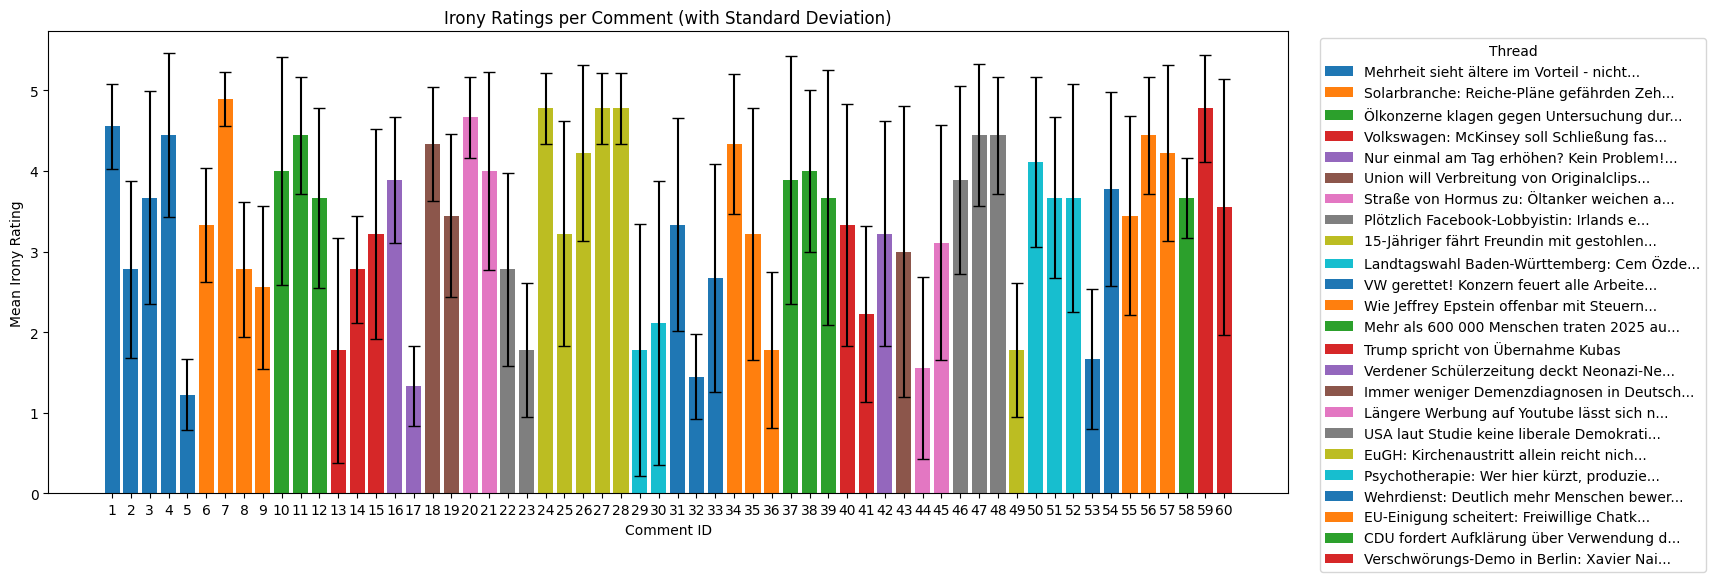

In [15]:
# Create numeric x positions
x = range(len(comment_stats_df))

# Use simple IDs for x-axis
labels = comment_stats_df["comment_id"]

# Assign colors per thread
threads = comment_stats_df["thread"].unique()
cmap = plt.get_cmap("tab10")
thread_colors = {thread: cmap(i % 10) for i, thread in enumerate(threads)}

colors = comment_stats_df["thread"].map(thread_colors)

plt.figure(figsize=(16, 6))

# Bar plot with error bars (standard deviation)
plt.bar(
    x,
    comment_stats_df["mean_irony"],
    yerr=comment_stats_df["std_irony"],
    capsize=4,
    color=colors
)

# Clean x-axis
plt.xticks(x, labels, rotation=0)
plt.xlabel("Comment ID")
plt.ylabel("Mean Irony Rating")
plt.title("Irony Ratings per Comment (with Standard Deviation)")

# Legend for threads
legend_elements = [
    Patch(facecolor=thread_colors[t], label=t[:40] + "..." if len(t) > 40 else t)
    for t in threads
]

plt.legend(
    handles=legend_elements,
    title="Thread",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.savefig("outputs/figures/human/irony_per_comment.png", dpi=300, bbox_inches="tight")
plt.show()

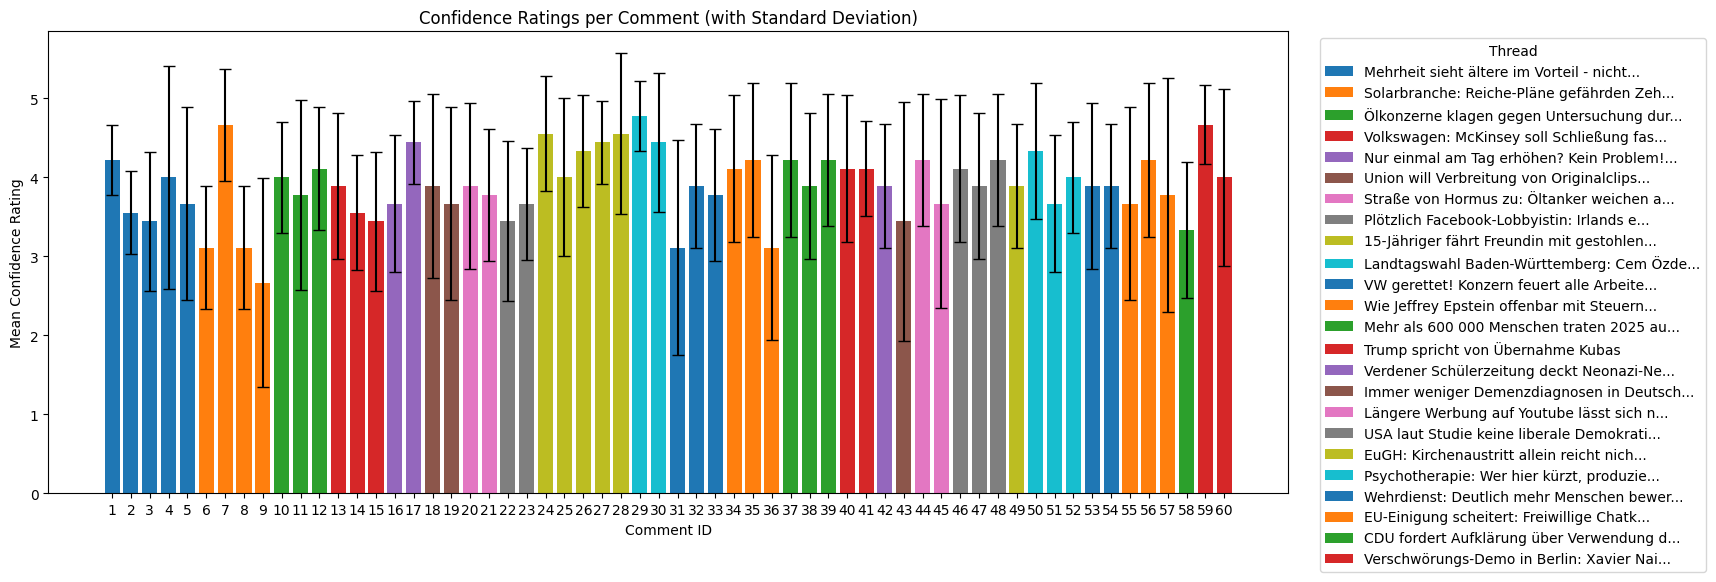

In [16]:
# Create numeric x positions
x = range(len(comment_stats_df))

# Use simple IDs for x-axis
labels = comment_stats_df["comment_id"]

# Assign colors per thread
threads = comment_stats_df["thread"].unique()
cmap = plt.get_cmap("tab10")
thread_colors = {thread: cmap(i % 10) for i, thread in enumerate(threads)}

colors = comment_stats_df["thread"].map(thread_colors)

plt.figure(figsize=(16, 6))

# Bar plot with error bars (standard deviation)
plt.bar(
    x,
    comment_stats_df["mean_confidence"],
    yerr=comment_stats_df["std_confidence"],
    capsize=4,
    color=colors
)

# Clean x-axis
plt.xticks(x, labels, rotation=0)
plt.xlabel("Comment ID")
plt.ylabel("Mean Confidence Rating")
plt.title("Confidence Ratings per Comment (with Standard Deviation)")

# Legend for threads
legend_elements = [
    Patch(facecolor=thread_colors[t], label=t[:40] + "..." if len(t) > 40 else t)
    for t in threads
]

plt.legend(
    handles=legend_elements,
    title="Thread",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.savefig("outputs/figures/human/confidence_per_comment.png", dpi=300, bbox_inches="tight")
plt.show()

### Relationship between Irony and Confidence  
Is stronger irony associated with higher annotator confidence?

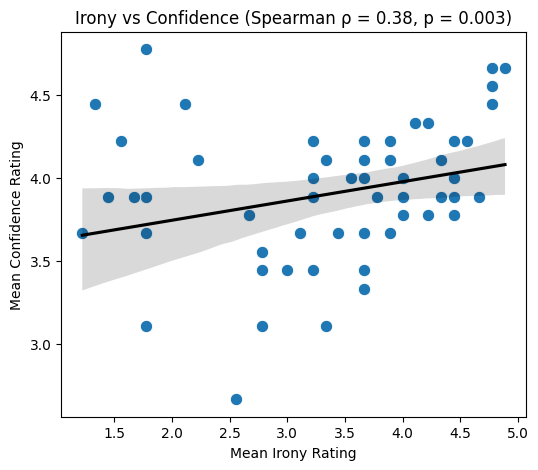

In [17]:
# Compute correlation (just to show it in the plot)
# rho: strength of correlation
# p: significance of the correlation
rho, p = spearmanr(
    comment_stats_df["mean_irony"],
    comment_stats_df["mean_confidence"]
)

plt.figure(figsize=(6, 5))

# Scatter plot
sns.scatterplot(
    data=comment_stats_df,
    x="mean_irony",
    y="mean_confidence",
    s=80
)

# Regression line
sns.regplot(
    data=comment_stats_df,
    x="mean_irony",
    y="mean_confidence",
    scatter=False,
    color="black"
)

# Labels
plt.xlabel("Mean Irony Rating")
plt.ylabel("Mean Confidence Rating")
plt.title(f"Irony vs Confidence (Spearman ρ = {rho:.2f}, p = {p:.3f})")

plt.savefig("outputs/figures/human/irony_vs_confidence.png", dpi=300, bbox_inches="tight")
plt.show()

- Moderate positive correlation (ρ = 0.38)
- Statistically significant (p = 0.003)
  - The possibility to observe this relation at random is only 0.3%!
- Higher irony --> slightly higher confidence
- Considerable variability --> effect not strong

## Measurements

### Cronbach's Alpha
#### Reliability coefficient and a measure of the internal consistency of our survey
**Irony alpha**: Are all comments consistenly measuring irony?

**Confidence alpha**: Are annotators consistent in how confident they feel?

In [18]:
def cronbach_alpha(df):
    k = df.shape[1]
    variance_sum = df.var(axis=0, ddof=1).sum()
    total_var = df.sum(axis=1).var(ddof=1)

    return (k / (k - 1)) * (1 - (variance_sum / total_var))

In [19]:
alpha_irony = cronbach_alpha(irony)
alpha_confidence = cronbach_alpha(confidence)

In [20]:
alpha_irony

np.float64(0.8082579570525372)

In [21]:
alpha_confidence

np.float64(0.8973080757726819)

- Irony alpha ≈ 0.81 --> good
  - Die Teilnehmer interpretieren Ironie über alle Kommentare hinweg auf einheitliche Weise
- Confidence ≈ 0.9 --> very good
  - Sehr hohe Konsistenz
  - Die Konfidenz verhält sich sehr stabil

### Krippendorf's Kappa
#### How much do annotators agree with each other, beyond chance?
In our case it answers "Do annotators assign similar irony ratings to the same comments?"

In [22]:
irony.values.shape

(9, 60)

In [23]:
krippendorff.alpha(reliability_data=irony.values, level_of_measurement='ordinal')

np.float64(0.41496491978938344)

## Find problematic comments

In [24]:
irony.std(axis=0).sort_values(ascending=False)[:3]

KOMMENTAR #43\n\nTHREAD: Immer weniger Demenzdiagnosen in Deutschland\n\nKOMMENTAR: Es gibt auch noch positive Nachrichten?\n\nWie ironisch ist dieser Kommentar?                                                                       1.802776
KOMMENTAR #30\n\nTHREAD: Landtagswahl Baden-Württemberg: Cem Özdemir lehnt Teilung der Amtszeit des Ministerpräsidenten ab\n\nKOMMENTAR: Eigentlich eine Schande sowas auch nur vorzuschlagen.\n\nWie ironisch ist dieser Kommentar?    1.763834
KOMMENTAR #60\n\nTHREAD: Verschwörungs-Demo in Berlin: Xavier Naidoo singt - deutlich weniger Teilnehmende als angekündigt\n\nKOMMENTAR: Dieser Weg ist peinlich und leer.\n\nWie ironisch ist dieser Kommentar?                        1.589899
dtype: float64

In [25]:
display(comment_stats_df[comment_stats_df["comment_id"] == 25])
display(comment_stats_df[comment_stats_df["comment_id"] == 33])
display(comment_stats_df[comment_stats_df["comment_id"] == 15])

,comment_id,thread,comment,mean_irony,var_irony,std_irony,mean_confidence,var_confidence,std_confidence
24,25,15-Jähriger fährt Freundin mit gestohlenem Lin...,"Also wenn ich die Freundin wäre, ich hätte den...",3.222222,1.944444,1.394433,4.0,1.0,1.0


,comment_id,thread,comment,mean_irony,var_irony,std_irony,mean_confidence,var_confidence,std_confidence
32,33,VW gerettet! Konzern feuert alle Arbeiter und ...,"Unironisch könnte man viele Konzerne retten, w...",2.666667,2.0,1.414214,3.777778,0.694444,0.833333


,comment_id,thread,comment,mean_irony,var_irony,std_irony,mean_confidence,var_confidence,std_confidence
14,15,Volkswagen: McKinsey soll Schließung fast alle...,Was die dann an personalkosten sparen können s...,3.222222,1.694444,1.301708,3.444444,0.777778,0.881917


In [27]:
# hohe Einigkeit = niedrige std
best_example = comment_stats_df.sort_values("std_irony").iloc[0]
best_example

comment_id                                                         7
thread             Solarbranche: Reiche-Pläne gefährden Zehntause...
comment            Leute alles gut. Laut der EU Präsidentin krieg...
mean_irony                                                  4.888889
var_irony                                                   0.111111
std_irony                                                   0.333333
mean_confidence                                             4.666667
var_confidence                                                   0.5
std_confidence                                              0.707107
Name: 6, dtype: object

In [40]:
print(best_example["thread"])
print(best_example["comment"])

Solarbranche: Reiche-Pläne gefährden Zehntausende Jobs
Leute alles gut. Laut der EU Präsidentin kriegen wir bald eh alle kleine Mini AKWs und dann jeder seinen eigenen Atompilz im Keller


In [28]:
worst_example = comment_stats_df.sort_values("std_irony", ascending=False).iloc[0]
worst_example

comment_id                                                   43
thread             Immer weniger Demenzdiagnosen in Deutschland
comment                 Es gibt auch noch positive Nachrichten?
mean_irony                                                  3.0
var_irony                                                  3.25
std_irony                                              1.802776
mean_confidence                                        3.444444
var_confidence                                         2.277778
std_confidence                                         1.509231
Name: 42, dtype: object

In [41]:
print(worst_example["thread"])
print(worst_example["comment"])

Immer weniger Demenzdiagnosen in Deutschland
Es gibt auch noch positive Nachrichten?


In [36]:
col_idx = best_example.name   # original row index in comment_stats_df

irony_ratings = irony.iloc[:, col_idx]
confidence_ratings = confidence.iloc[:, col_idx]

print("Irony:", irony_ratings.to_list())
print("Confidence:", confidence_ratings.to_list())

Irony: [5, 5, 4, 5, 5, 5, 5, 5, 5]
Confidence: [5, 5, 4, 5, 5, 5, 3, 5, 5]


In [37]:
col_idx = worst_example.name

irony_ratings = irony.iloc[:, col_idx]
confidence_ratings = confidence.iloc[:, col_idx]

print("Irony:", irony_ratings.to_list())
print("Confidence:", confidence_ratings.to_list())

Irony: [1, 1, 5, 1, 2, 5, 5, 4, 3]
Confidence: [4, 5, 4, 4, 1, 5, 4, 1, 3]


## Compare agreement vs confidence
Do annotators behave consistently / overconfidently?

In [26]:
agreement = irony.std(axis=1)
confidence_mean = confidence.mean(axis=1)

spearmanr(agreement, confidence_mean)

SignificanceResult(statistic=np.float64(0.7447763937925935), pvalue=np.float64(0.02131972812332017))